In [10]:
# Les Tracés sur (15,k,d) sur F2

q = 2
F = GF(q)
n = 15

def volume_hamming(n, r, q):
    return sum(binomial(n, i)*(q-1)^i for i in range(r+1))
print(f"Le volume de la boule V_q(c,r):{volum_hamming(n, 2, q)}")

Le volume de la boule V_q(c,r):121


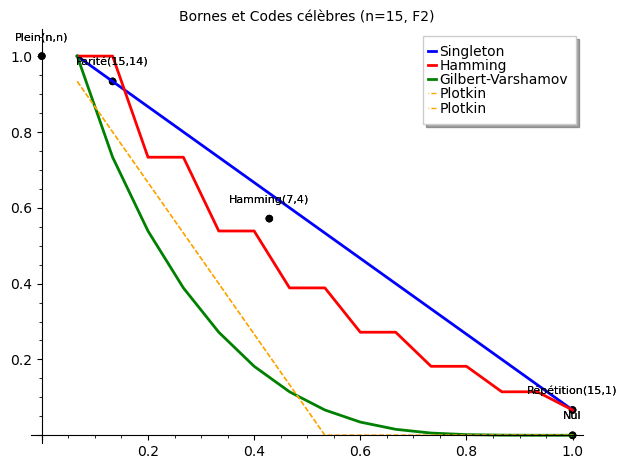

In [16]:
# Initialisation des listes de points (abscisse delta, ordonnée R)
singleton_pts = []
hamming_pts = []
gv_pts = []

for d in range(1, n + 1):
    delta = d / n
    
    # 1. Borne de Singleton : k <= n - d + 1
    k_s = n - d + 1
    singleton_pts.append((delta, k_s / n))
    
    # 2. Borne de Hamming : k <= n - log_q(Volume(n, floor((d-1)/2)))
    t = (d - 1) // 2
    vol_h = volume_hamming(n, t, q)
    k_h = n - log(vol_h, q)
    hamming_pts.append((delta, k_h / n))
    
    # 3. Borne de Gilbert-Varshamov : k >= n - log_q(Volume(n, d-1))
    vol_gv = volume_hamming(n, d - 1, q)
    k_gv = n - log(vol_gv, q)
    gv_pts.append((delta, k_gv / n))
    # 4. Borne de Plotkin (cas binaire q=2)
    plotkin_pts = []
    for d in range(1, n + 1):
        delta = d / n
        if delta < 0.5:
            k_p = n - 2*d + 1 # Formule simplifiée pour n, d petits
            if k_p < 0: k_p = 0
            plotkin_pts.append((delta, k_p / n))
        else:
            plotkin_pts.append((delta, 0))

# 5. Codes célèbres (Question 2) 
# Hamming(7,4) -> d=3, n=7 => delta=3/7, R=4/7
# Repétition(15,1) -> d=15, n=15 => delta=1, R=1/15
# Parité(15,14) -> d=2, n=15 => delta=2/15, R=14/15
codes_connus = [
    (3/7, 4/7, "Hamming(7,4)"),
    (1, 1/15, "Répétition(15,1)"),
    (2/15, 14/15, "Parité(15,14)"),
    (0, 1, "Plein(n,n)"),
    (1, 0, "Nul")
]

# Mise à jour du graphique
p += line(plotkin_pts, color='orange', legend_label='Plotkin', linestyle="--")

for delta_c, r_c, label in codes_connus:
    p += point((delta_c, r_c), size=30, color='black')
    p += text(label, (delta_c, r_c + 0.05), fontsize=8, color='black')

show(p, title="Bornes et Codes célèbres (n=15, F2)")

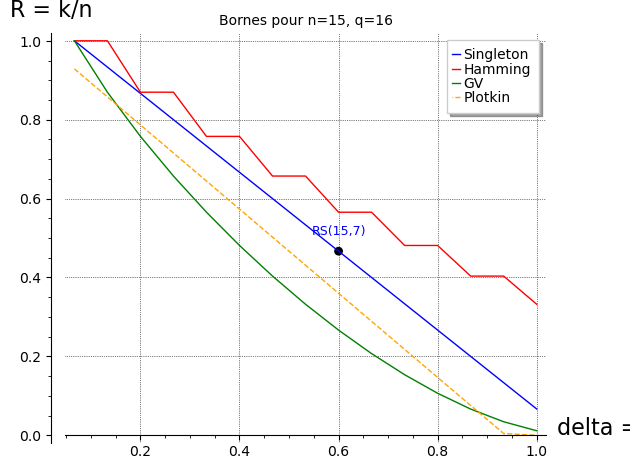

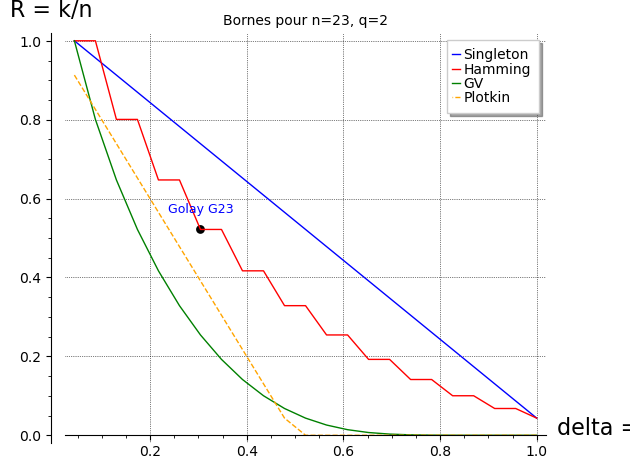

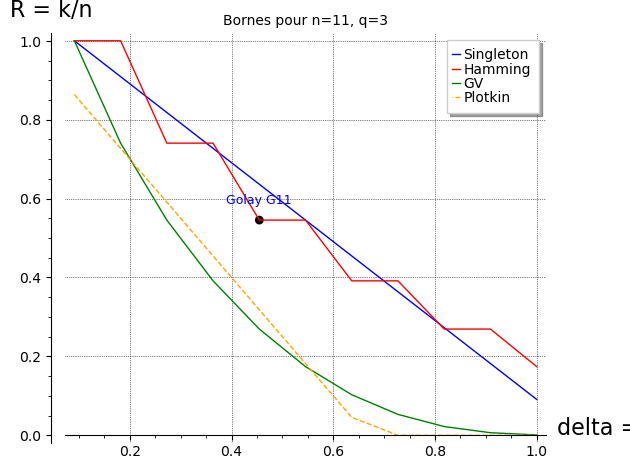

In [17]:
def tracer_bornes(n, q, codes_specifiques=[]):
    d_range = range(1, n + 1)
    
    # Calcul des bornes
    singleton = [(d/n, (n-d+1)/n) for d in d_range]
    hamming = [(d/n, (n - log(volume_hamming(n, (d-1)//2, q), q))/n) for d in d_range]
    gv = [(d/n, max(0, (n - log(volume_hamming(n, d-1, q), q))/n)) for d in d_range]
    
    # Borne de Plotkin simplifiée
    plotkin = []
    theta = (q-1)/q
    for d in d_range:
        delta = d/n
        if delta < theta:
            R_p = 1 - (delta / theta)
            plotkin.append((delta, max(0, R_p)))
        else:
            plotkin.append((delta, 0))

    # Graphique
    p = line(singleton, color='blue', legend_label='Singleton')
    p += line(hamming, color='red', legend_label='Hamming')
    p += line(gv, color='green', legend_label='GV')
    p += line(plotkin, color='orange', linestyle="--", legend_label='Plotkin')

    # Ajout des codes spécifiques (Question 2)
    for d_c, k_c, label in codes_specifiques:
        p += point((d_c/n, k_c/n), size=40, color='black')
        p += text(label, (d_c/n, k_c/n + 0.05), fontsize=9)

    p.axes_labels(['delta = d/n', 'R = k/n'])
    show(p, title=f"Bornes pour n={n}, q={q}", gridlines=True, ymin=0, ymax=1)

# --- TRACÉ POUR F16 (n=15, q=16) ---
# On y place un code de Reed-Solomon [15, 7, 9]
tracer_bornes(15, 16, [(9, 7, "RS(15,7)")])

# --- TRACÉ POUR GOLAY BINAIRE (n=23, q=2) ---
# Le code de Golay parfait [23, 12, 7]
tracer_bornes(23, 2, [(7, 12, "Golay G23")])

# --- TRACÉ POUR GOLAY TERNAIRE (n=11, q=3) ---
# Le code de Golay ternaire [11, 6, 5]
tracer_bornes(11, 3, [(5, 6, "Golay G11")])